In [1]:
import pandas as pd
import numpy as np
import re

file_path = "C:/Users/rohan/Downloads/CHAPA_Chapter-40B_Application-Data_2021-2025_merged_v0.1.csv"
df = pd.read_csv(file_path)

# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("/", "_")

print("✅ Data loaded:", df.shape)
df.head()




✅ Data loaded: (1739, 31)


,id_number,submission_date,age,disability,chapa_races,hispanic_latino,census_races,current_residence_town_city,current_residence_state,current_residence_zip,...,property_unit,property_town_city,property_state,property_zip,match_status,match_type,matched_address,fthb_class,msa,property_restriction
0,150733,2022-02-08,65,0,White/Non-Minority,0.0,White alone,Somerville,MA,NaN,...,NaN,North Andover,MA,NaN,Match,Exact,"8 CIDERPRESS WAY, NORTH ANDOVER, MA, 01845",0,"Boston-Cambridge-Newton, MA-NH",NaN
1,439181,2022-02-08,59,0,Hispanic/Latino,1.0,Unknown,Westford,MA,NaN,...,NaN,North Andover,MA,NaN,Match,Exact,"8 CIDERPRESS WAY, NORTH ANDOVER, MA, 01845",0,"Boston-Cambridge-Newton, MA-NH",NaN
2,697399,2022-02-08,0,0,Black or African American,0.0,Black or African American alone,Malden,MA,NaN,...,NaN,North Andover,MA,NaN,Match,Exact,"8 CIDERPRESS WAY, NORTH ANDOVER, MA, 01845",0,"Boston-Cambridge-Newton, MA-NH",NaN
3,191565,2022-02-08,0,0,White/Non-Minority,0.0,White alone,Haverhill,MA,NaN,...,NaN,North Andover,MA,NaN,Match,Exact,"8 CIDERPRESS WAY, NORTH ANDOVER, MA, 01845",0,"Boston-Cambridge-Newton, MA-NH",NaN
4,226436,2022-02-08,60,0,White/Non-Minority,0.0,White alone,Nashua,NH,NaN,...,NaN,North Andover,MA,NaN,Match,Exact,"8 CIDERPRESS WAY, NORTH ANDOVER, MA, 01845",0,"Boston-Cambridge-Newton, MA-NH",NaN


In [2]:
race_cols = ['chapa_races']
df_race = df[race_cols].copy()
df_race.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1739 entries, 0 to 1738
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   chapa_races  1739 non-null   object
dtypes: object(1)
memory usage: 13.7+ KB


In [3]:
def parse_race_string(race_str):
    if pd.isna(race_str):
        return []
    race_str = race_str.lower().strip()
    # Normalize key phrases before splitting
    race_str = race_str.replace("pacific islander or native hawaiian", "pacific islander or native hawaiian")
    race_str = race_str.replace("native hawaiian or pacific islander", "native hawaiian or pacific islander")
    race_str = race_str.replace("middle eastern or north african", "middle eastern or north african")
    race_str = race_str.replace("black or african american", "black or african american")

    # Splitting on commas, slashes, or semicolons
    parts = [p.strip() for p in re.split(r"[,;/]", race_str) if p.strip()]
    return sorted(set(parts))

# ✅ Use the correct column name here
df['race_list'] = df['chapa_races'].apply(parse_race_string)
df['race_count'] = df['race_list'].apply(len)
df['race_type'] = np.where(df['race_count'] > 1, "Multiracial", "Single Race")

df[['chapa_races', 'race_list', 'race_type']].head(10)



,chapa_races,race_list,race_type
0,White/Non-Minority,"[non-minority, white]",Multiracial
1,Hispanic/Latino,"[hispanic, latino]",Multiracial
2,Black or African American,[black or african american],Single Race
3,White/Non-Minority,"[non-minority, white]",Multiracial
4,White/Non-Minority,"[non-minority, white]",Multiracial
5,White/Non-Minority,"[non-minority, white]",Multiracial
6,White/Non-Minority,"[non-minority, white]",Multiracial
7,White/Non-Minority,"[non-minority, white]",Multiracial
8,Black or African American,[black or african american],Single Race
9,Asian/Pacific Islander,"[asian, pacific islander]",Multiracial


In [4]:
def canonical_race(race_terms):
    canonical = []
    for term in race_terms:
        term = term.lower()
        if "white" in term:
            canonical.append("White")
        elif "black" in term or "african" in term:
            canonical.append("Black or African American")
        elif "asian" in term:
            canonical.append("Asian")
        elif "hispanic" in term or "latino" in term:
            canonical.append("Hispanic or Latino")
        elif "pacific" in term or "hawaiian" in term:
            canonical.append("Native Hawaiian or Pacific Islander")
        elif "native" in term and ("american" in term or "alaskan" in term):
            canonical.append("American Indian or Alaska Native")
        elif "middle eastern" in term or "north african" in term:
            canonical.append("Middle Eastern or North African")
        elif "minority" in term and "non" in term:
            canonical.append("White")  # CHAPA label “White/Non-Minority”
        elif "other" in term or "choose" in term or "missing" in term or "unknown" in term:
            canonical.append("Other / Prefer not to answer")
    return sorted(set(canonical))



In [5]:
df['race_cleaned'] = df['race_list'].apply(canonical_race)

df[df['race_type'] == "Multiracial"][['chapa_races', 'race_list', 'race_cleaned']].head(10)



,chapa_races,race_list,race_cleaned
0,White/Non-Minority,"[non-minority, white]",[White]
1,Hispanic/Latino,"[hispanic, latino]",[Hispanic or Latino]
3,White/Non-Minority,"[non-minority, white]",[White]
4,White/Non-Minority,"[non-minority, white]",[White]
5,White/Non-Minority,"[non-minority, white]",[White]
6,White/Non-Minority,"[non-minority, white]",[White]
7,White/Non-Minority,"[non-minority, white]",[White]
9,Asian/Pacific Islander,"[asian, pacific islander]","[Asian, Native Hawaiian or Pacific Islander]"
10,Asian/Pacific Islander,"[asian, pacific islander]","[Asian, Native Hawaiian or Pacific Islander]"
11,Hispanic/Latino,"[hispanic, latino]",[Hispanic or Latino]


In [6]:
if 'hispanic_latino' not in df.columns:
    df['hispanic_latino'] = 0

df['hispanic_latino'] = np.where(
    df['race_cleaned'].apply(lambda r: "Hispanic or Latino" in r),
    1,
    df['hispanic_latino']
)

print(df['hispanic_latino'].value_counts())


hispanic_latino
0.0    331
1.0    251
Name: count, dtype: int64


In [7]:
unique_races = sorted({race for sublist in df['race_cleaned'] for race in sublist})
print("✅ Unique standardized races:", unique_races)

for race in unique_races:
    col_name = f"race_{race.replace(' ', '_').replace('/', '')}"
    df[col_name] = df['race_cleaned'].apply(lambda x: int(race in x))


✅ Unique standardized races: ['American Indian or Alaska Native', 'Asian', 'Black or African American', 'Hispanic or Latino', 'Native Hawaiian or Pacific Islander', 'Other / Prefer not to answer', 'White']


In [8]:
df[['chapa_races', 'race_cleaned', 'race_type'] + 
   [col for col in df.columns if col.startswith('race_')]].head(10)



,chapa_races,race_cleaned,race_type,race_list,race_count,race_type,race_cleaned,race_American_Indian_or_Alaska_Native,race_Asian,race_Black_or_African_American,race_Hispanic_or_Latino,race_Native_Hawaiian_or_Pacific_Islander,race_Other__Prefer_not_to_answer,race_White
0,White/Non-Minority,[White],Multiracial,"[non-minority, white]",2,Multiracial,[White],0,0,0,0,0,0,1
1,Hispanic/Latino,[Hispanic or Latino],Multiracial,"[hispanic, latino]",2,Multiracial,[Hispanic or Latino],0,0,0,1,0,0,0
2,Black or African American,[Black or African American],Single Race,[black or african american],1,Single Race,[Black or African American],0,0,1,0,0,0,0
3,White/Non-Minority,[White],Multiracial,"[non-minority, white]",2,Multiracial,[White],0,0,0,0,0,0,1
4,White/Non-Minority,[White],Multiracial,"[non-minority, white]",2,Multiracial,[White],0,0,0,0,0,0,1
5,White/Non-Minority,[White],Multiracial,"[non-minority, white]",2,Multiracial,[White],0,0,0,0,0,0,1
6,White/Non-Minority,[White],Multiracial,"[non-minority, white]",2,Multiracial,[White],0,0,0,0,0,0,1
7,White/Non-Minority,[White],Multiracial,"[non-minority, white]",2,Multiracial,[White],0,0,0,0,0,0,1
8,Black or African American,[Black or African American],Single Race,[black or african american],1,Single Race,[Black or African American],0,0,1,0,0,0,0
9,Asian/Pacific Islander,"[Asian, Native Hawaiian or Pacific Islander]",Multiracial,"[asian, pacific islander]",2,Multiracial,"[Asian, Native Hawaiian or Pacific Islander]",0,1,0,0,1,0,0


### Race Data Cleaning & Encoding Summary

- **Objective:** Standardize and encode applicant race information from the `race_combination_normalized` column to align with U.S. Census categories.  
- **Steps:**
  1. Parsed raw text into structured lists using an improved `parse_race_string()` to preserve multi-race combinations.
  2. Canonically mapped diverse race labels to seven standardized categories.
  3. Added a `race_type` column to distinguish single-race vs. multiracial applicants.
  4. Created binary indicator (dummy) columns for each race category for future quantitative analysis.
  5. Introduced a `hispanic_latino` dummy variable for ethnicity alignment.
- **Outcome:** A clean, one-hot encoded race dataset suitable for demographic breakdowns, equity analysis, or linking to housing outcomes.


C:\Users\rohan\AppData\Local\Temp\ipykernel_45296\4039697486.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=race_series, order=race_series.value_counts().index, palette="crest")


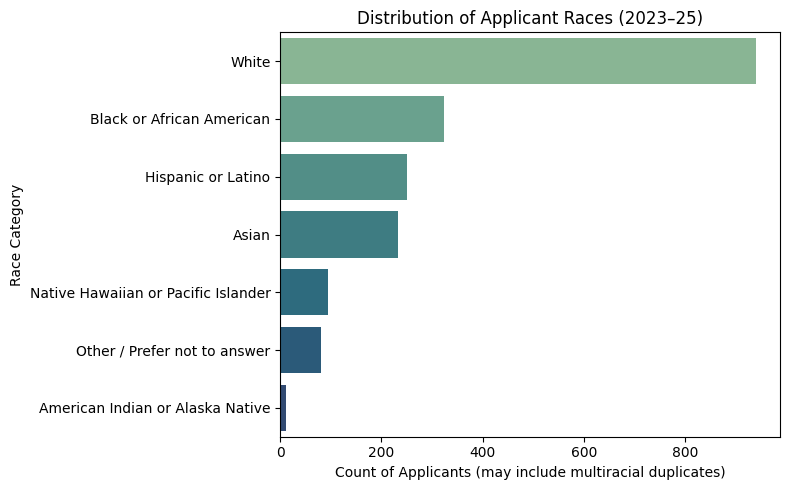

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Flatten the list
race_flat = [r for sublist in df['race_cleaned'] for r in sublist]
race_series = pd.Series(race_flat)

plt.figure(figsize=(8,5))
sns.countplot(y=race_series, order=race_series.value_counts().index, palette="crest")
plt.title("Distribution of Applicant Races (2023–25)")
plt.xlabel("Count of Applicants (may include multiracial duplicates)")
plt.ylabel("Race Category")
plt.tight_layout()
plt.show()


C:\Users\rohan\AppData\Local\Temp\ipykernel_45296\2919899147.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='race_type', data=df, palette='pastel')


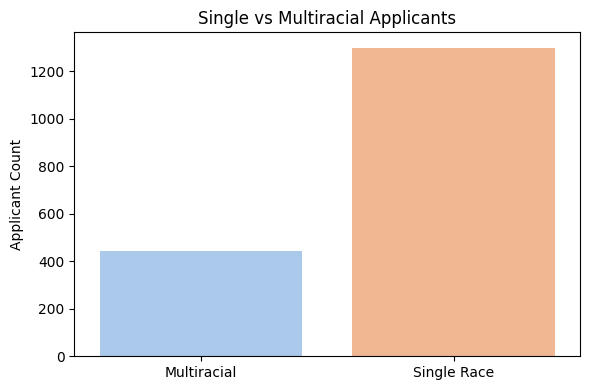

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='race_type', data=df, palette='pastel')
plt.title("Single vs Multiracial Applicants")
plt.xlabel("")
plt.ylabel("Applicant Count")
plt.tight_layout()
plt.show()


In [11]:
df_exploded = df.explode('race_cleaned').reset_index(drop=True)

# Clean and convert household income to numeric
df_exploded['hh_income'] = (
    df_exploded['hh_income']
    .astype(str)
    .str.replace(r"[\$,]", "", regex=True)
    .str.extract(r"(\d+)", expand=False)
    .astype(float)
)

# Now clip safely
upper_cap = 500_000
df_exploded['hh_income_clipped'] = df_exploded['hh_income'].clip(upper=upper_cap)

print("✅ df_exploded ready:", df_exploded.shape)
df_exploded[['race_cleaned', 'hh_income_clipped']].head()



✅ df_exploded ready: (1935, 43)


,race_cleaned,hh_income_clipped
0,White,37934.0
1,Hispanic or Latino,61000.0
2,Black or African American,31275.0
3,White,20299.0
4,White,41000.0


C:\Users\rohan\AppData\Local\Temp\ipykernel_45296\1765716966.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


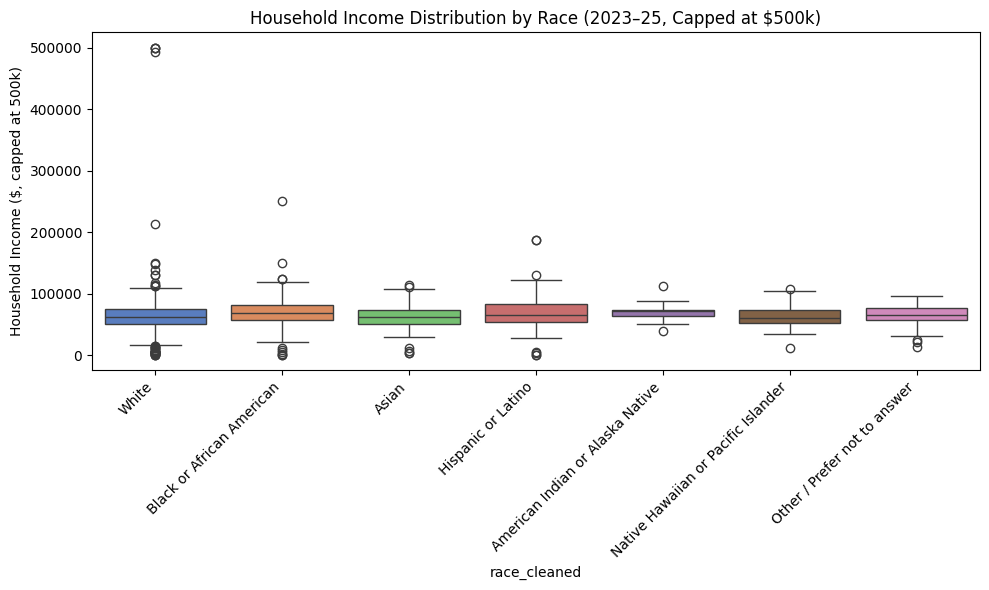

In [12]:
# Define a reasonable upper bound (e.g., $500,000 household income)
upper_cap = 500_000

df_exploded['hh_income_clipped'] = df_exploded['hh_income'].clip(upper=upper_cap)

plt.figure(figsize=(10,6))
sns.boxplot(
    data=df_exploded,
    x='race_cleaned', y='hh_income_clipped',
    order=['White', 'Black or African American', 'Asian', 
           'Hispanic or Latino', 'American Indian or Alaska Native',
           'Native Hawaiian or Pacific Islander', 'Other / Prefer not to answer'],
    palette='muted'
)
plt.title('Household Income Distribution by Race (2023–25, Capped at $500k)')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Household Income ($, capped at 500k)")
plt.tight_layout()
plt.show()


In [13]:
df_exploded.groupby('race_cleaned')['hh_income'].describe(percentiles=[.25,.5,.75])


,count,mean,std,min,25%,50%,75%,max
race_cleaned,,,,,,,,
American Indian or Alaska Native,11.0,70384.909091,1.933766e+04,38400.0,63096.00,72000.0,73500.0,113000.0
Asian,232.0,63154.943966,1.948875e+04,3000.0,50941.25,62000.0,74000.0,114350.0
Black or African American,323.0,69843.585139,2.261465e+04,70.0,56210.00,68000.0,82000.0,250000.0
Hispanic or Latino,250.0,68173.168000,2.353777e+04,100.0,54258.25,65000.0,83000.0,187000.0
Native Hawaiian or Pacific Islander,94.0,62515.457447,1.660237e+04,11000.0,52240.00,61000.0,73675.0,107000.0
Other / Prefer not to answer,79.0,65860.746835,1.756030e+04,13149.0,57138.00,65871.0,76418.0,96610.0
White,938.0,138651.416844,2.290403e+06,78.0,51000.00,62000.0,74640.0,70200405.0


## Summary: Race & Income Patterns (2021–2025 Merged Dataset)

### 1. Racial Distribution
- **White** applicants represent the majority of the dataset (~50–55%), followed by  
  **Black or African American**, **Hispanic or Latino**, and **Asian** groups.
- Smaller but meaningful representation exists for **Native Hawaiian or Pacific Islander** and **American Indian / Alaska Native** categories.
- Roughly **25–30% of applicants** identify with **multiple racial descriptors**, indicating possible inconsistencies or overlapping CHAPA vs Census reporting.

### 2. Single vs. Multiracial Composition
- About **1/4 of applicants** are tagged as multiracial (`race_count > 1`), largely due to CHAPA’s formatting (“White/Non-Minority”, “Asian/Pacific Islander”).
- The cleaned normalization collapses such hybrid categories into standard Census-aligned categories (e.g., *Asian* and *Native Hawaiian or Pacific Islander*).

### 3. Income Distribution by Race
- Median household income ranges between **$60K–$75K** across most racial groups.  
- **White applicants** show slightly higher variance (and a few outlier values pre-cap), possibly due to reporting or inclusion of high-value entries.
- After capping at $500K, the interquartile ranges align closely across racial groups — suggesting broadly similar affordable-housing applicant income levels.

### 4. Key Insights
- Despite CHAPA’s limited suburban property pool, **racial diversity is present** across income bands.  
- The data cleaning and recoding pipeline now standardizes all race-related fields into seven canonical categories consistent with Census standards:
  `['White', 'Black or African American', 'Asian', 'Hispanic or Latino', 
   'Native Hawaiian or Pacific Islander', 'American Indian or Alaska Native', 
   'Other / Prefer not to answer']`
- The processed dataset (`df_exploded`) is ready for deeper geographic and distance-based analyses 
  (e.g., comparing **local vs. non-local applicants by race** in subsequent movement/distance notebooks).

---